In [17]:
from skimage.io import imread
import numpy as np
from matplotlib import pyplot as plt

In [18]:
rootfolder = '..'

Load the image and rescale it in $[0,1]$

In [19]:
img = imread(f'{rootfolder}/data/cameraman.png') / 255
img = img[50:200, 50:200]
imsz = img.shape

# patch size
p = 7

k = p//2

# number of elements in the patch
M = p ** 2

# radius of the search neighborhood
H = 12

Corrupt the image with white gaussian noise

In [20]:
sigma_noise = 20/255
noisy_img = img + sigma_noise * np.random.normal(size=imsz)

Compute the PSNR of the noisy input

In [21]:
psnr_noisy = 10 * np.log10(1 / np.mean((img - noisy_img)**2))

Text(0.5, 1.0, 'Noisy image, PSNR = 22.04')

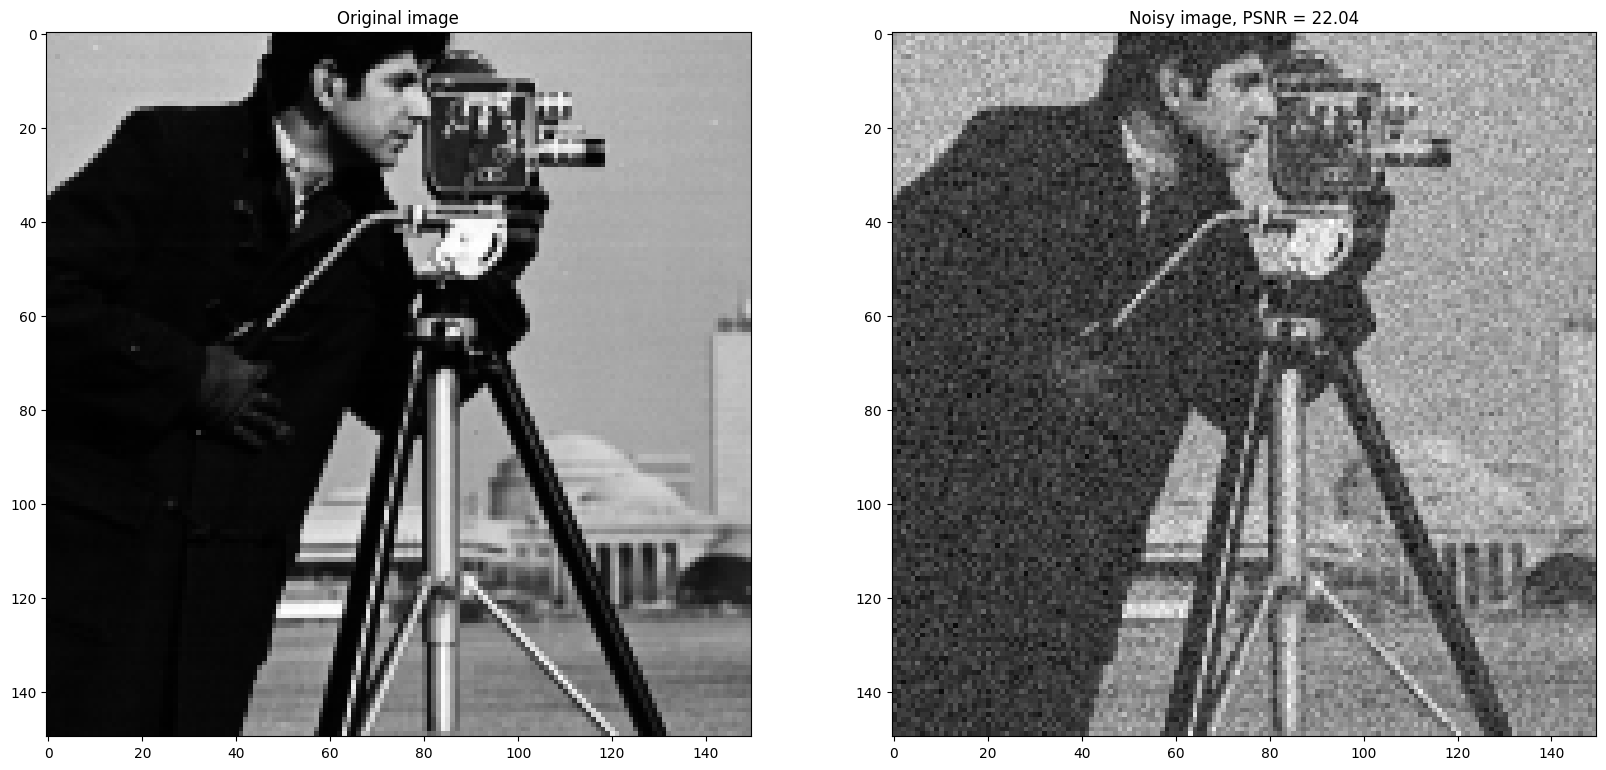

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')

Pixel-based NL-Means
--------------------
Set parameters and initialize the variables

In [23]:
# initialize the estimated image
img_hat = np.zeros_like(img)

# pad the noisy image
img_pad = np.pad(noisy_img, p//2, 'symmetric')

Main loop

In [24]:
for r in range(0, imsz[0]):
    for c in range(0, imsz[1]):
        # extrach the patch from img_pad whose center has the location (r, c) in the noisy image
        
        # center of the patch in padded image: (r_patch, c_patch) = (r+k, c+k)
        # img_pad[r_patch-k : r_patch+k+1, c_patch-k : c_patch+k+1]
        # substituting r_patch = r+k, c_patch = c+k:
        # img_pad[(r+k)-k : (r+k)+k+1, (c+k)-k : (c+k)+k+1] = img_pad[r : r+p, c : c+p]
        s = img_pad[r:r+p, c:c+p]

        # initialize the pixel estimate and the total weights
        pixel_hat = 0
        weight = 0

        # extract all the patches in the search neighborhood
        for i in range(-H, H+1):
            for j in range(-H, H+1):
                if k <= r+i < imsz[0]-k and k <= c+j < imsz[1]-k:
                    # extract the patch centered in (r+k+i, c+k+j)
                    z = img_pad[r+i : r+i+p, c+j : c+j+p]

                    # compute the distance with the reference patch
                    d = np.exp(-np.linalg.norm(s-z)**2 / (M * sigma_noise**2))

                    # update the weight and the pixel estimate
                    pixel_hat += d * img_pad[r+i+k, c+j+k]
                    weight += d

        # estimate the pixel (r, c) as the weighted average of the central pixel of the extracted patches
        img_hat[r, c] = pixel_hat / weight


Compute the PSNR of the estimated image

Text(0.5, 1.0, 'Estimated Image,\nPSNR = 27.31')

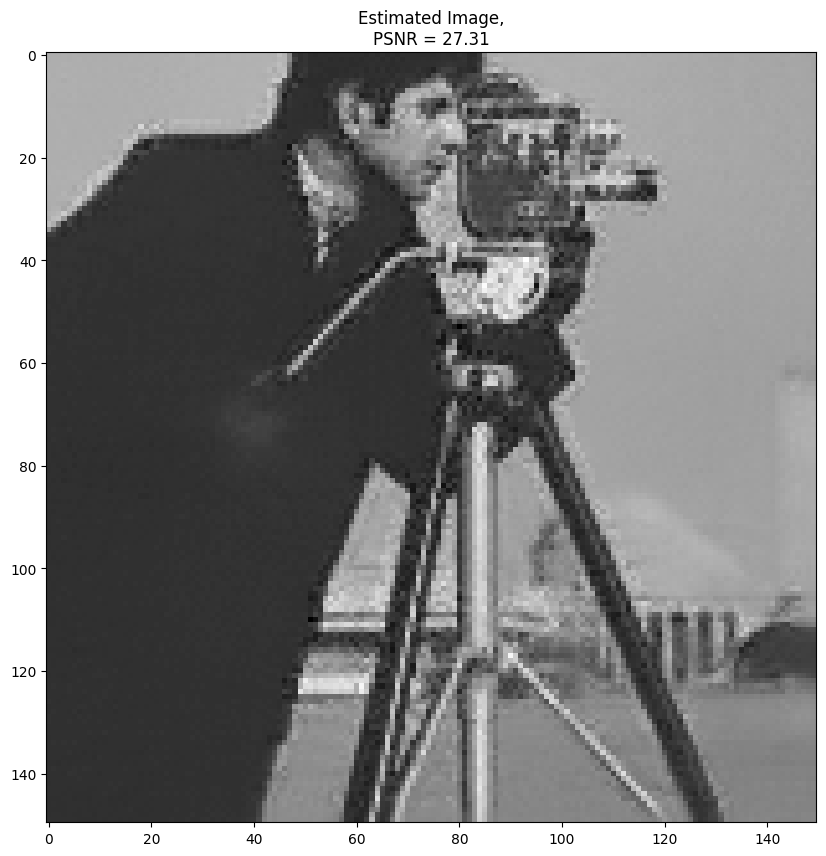

In [25]:
psnr_hat = 10 * np.log10(1 / np.mean((img - img_hat)**2))
plt.figure(figsize=(10,10))
plt.imshow(img_hat, cmap='gray')
plt.title(f'Estimated Image,\nPSNR = {psnr_hat:.2f}')